In [ ]:
!pip install optuna -q

In [ ]:
!pip install koreanize-matplotlib

In [ ]:
# 필요 라이브러리 임포트
import os
import random
import pickle
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

import time
from tqdm import tqdm
from copy import deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,             # AUROC
    average_precision_score,   # AUPR
    recall_score,              # Recall
    f1_score,                  # F1
    fbeta_score,               # F-beta
    precision_score,           # Precision (F1 계산 참고용)
    confusion_matrix           # TP/FP/TN/FN 확인용
)

In [ ]:
# ================================
# 0) 재현성(reproducibility) 설정
# ================================
def set_seed(seed: int = 11) -> None:
    """실험 결과를 최대한 재현 가능하게 만들기 위한 시드 고정 함수"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # GPU 사용 시 GPU용 난수 시드도 함께 고정
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

In [ ]:
# ===================================================
# 하이퍼파라미터 (Supplementary Table S3. MOLI_Complete_Pan_Drug)
# ===================================================

# Encoder
HIDDEN_DIM_EXPR = 32
HIDDEN_DIM_MUT  = 16
HIDDEN_DIM_CNA  = 256

# Drug Embedding
DRUG_TO_IDX = {
    'Cetuximab' : 0,
    'Afatinib'  : 1,
    'Erlotinib' : 2,
    'Gefitinib' : 3,
    'Lapatinib' : 4
}
IDX_TO_DRUG  = {v: k for k, v in DRUG_TO_IDX.items()}
NUM_DRUGS    = len(DRUG_TO_IDX)   # 5
DRUG_EMB_DIM = 8                  # 약물 임베딩 차원

# Classifier
Z_IN            = HIDDEN_DIM_EXPR + HIDDEN_DIM_MUT + HIDDEN_DIM_CNA  # 304
Z_TOTAL = Z_IN + DRUG_EMB_DIM     # 304 + 8 = 312

# Learning Rate
LR_EXPR = 0.001
LR_MUT  = 0.0001
LR_CNA  = 5e-5
LR_CLS  = 0.005

# Dropout
DROPOUT_EXPR = 0.5
DROPOUT_MUT  = 0.8
DROPOUT_CNA  = 0.5
DROPOUT_CLS  = 0.3

# 학습 설정
WEIGHT_DECAY = 0.0001
BATCH_SIZE   = 16
GAMMA        = 0.5
MARGIN       = 1.5
EPOCHS       = 20
FOLDS        = 5   # 추후 Cross Validation 구현 시 사용


print("📋 하이퍼파라미터 (Table S3 MOLI_Complete_Pan_Drug 기준)")
print(f"  Encoder hidden : expr={HIDDEN_DIM_EXPR} / mut={HIDDEN_DIM_MUT} / cna={HIDDEN_DIM_CNA}")
print(f"  Z_IN           : {Z_IN}  (encoder concat)")
print(f"  Drug Embedding : {NUM_DRUGS}약물 × {DRUG_EMB_DIM}차원")
print(f"  Z_TOTAL        : {Z_TOTAL}  (Z_IN + drug_emb)")
print(f"  LR             : expr={LR_EXPR} / mut={LR_MUT} / cna={LR_CNA} / cls={LR_CLS}")
print(f"  Dropout        : expr={DROPOUT_EXPR} / mut={DROPOUT_MUT} / cna={DROPOUT_CNA} / cls={DROPOUT_CLS}")
print(f"  weight_decay   : {WEIGHT_DECAY} (classifier only)")
print(f"  batch={BATCH_SIZE} / gamma={GAMMA} / margin={MARGIN} / epochs={EPOCHS}")

📋 하이퍼파라미터 (Table S3 MOLI_Complete_Pan_Drug 기준)
  Encoder hidden : expr=32 / mut=16 / cna=256
  Z_IN           : 304  (encoder concat)
  Drug Embedding : 5약물 × 8차원
  Z_TOTAL        : 312  (Z_IN + drug_emb)
  LR             : expr=0.001 / mut=0.0001 / cna=5e-05 / cls=0.005
  Dropout        : expr=0.5 / mut=0.8 / cna=0.5 / cls=0.3
  weight_decay   : 0.0001 (classifier only)
  batch=16 / gamma=0.5 / margin=1.5 / epochs=20


In [ ]:
# ===================================================
# 1) 데이터 로드
# ===================================================

BASE_DIR = "/content/drive/MyDrive/AI Health care 실습파일/MOLI"
save_dir = os.path.join(BASE_DIR, "preprocessed_EGFRi")

# Train
X_train_expr = np.load(f"{save_dir}/X_train_expr.npy")
X_train_mut  = np.load(f"{save_dir}/X_train_mut.npy")
X_train_cna  = np.load(f"{save_dir}/X_train_cna.npy")
drug_id_train = np.load(f"{save_dir}/drug_id_train.npy")
y_train      = np.load(f"{save_dir}/y_train.npy")

# Val (PDX)
X_val_expr   = np.load(f"{save_dir}/X_val_expr.npy")
X_val_mut    = np.load(f"{save_dir}/X_val_mut.npy")
X_val_cna    = np.load(f"{save_dir}/X_val_cna.npy")
drug_id_val  = np.load(f"{save_dir}/drug_id_val.npy")
y_val        = np.load(f"{save_dir}/y_val.npy")

# Val (TCGA)
X_tcga_expr  = np.load(f"{save_dir}/X_tcga_expr.npy")
X_tcga_mut   = np.load(f"{save_dir}/X_tcga_mut.npy")
X_tcga_cna   = np.load(f"{save_dir}/X_tcga_cna.npy")
drug_id_tcga = np.load(f"{save_dir}/drug_id_tcga.npy")
y_tcga       = np.load(f"{save_dir}/y_tcga.npy")

# 입력 차원
INPUT_DIM_EXPR = X_train_expr.shape[1]  # 18232
INPUT_DIM_MUT  = X_train_mut.shape[1]   # 14447
INPUT_DIM_CNA  = X_train_cna.shape[1]   # 20503

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("✅ 데이터 로드 완료")
print(f"  Train: {X_train_expr.shape[0]}샘플 | R:{int((y_train==0).sum())} S:{int((y_train==1).sum())}")
print(f"  PDX  : {X_val_expr.shape[0]}샘플   | R:{int((y_val==0).sum())} S:{int((y_val==1).sum())}")
print(f"  TCGA : {X_tcga_expr.shape[0]}샘플  | R:{int((y_tcga==0).sum())} S:{int((y_tcga==1).sum())}")
print(f"\n📐 입력 차원:")
print(f"  Expression : {INPUT_DIM_EXPR:,}")
print(f"  Mutation   : {INPUT_DIM_MUT:,}")
print(f"  CNA        : {INPUT_DIM_CNA:,}")
print(f"\n💊 Drug ID 확인:")
print(f"  Train drug_id : {drug_id_train.shape} dtype={drug_id_train.dtype}")
print(f"  Val   drug_id : {drug_id_val.shape}   dtype={drug_id_val.dtype}")
print(f"  TCGA  drug_id : {drug_id_tcga.shape}  dtype={drug_id_tcga.dtype}")
print(f"  매핑: {IDX_TO_DRUG}")
print(f"\n🖥️  장치: {device}")

✅ 데이터 로드 완료
  Train: 3258샘플 | R:2747 S:511
  PDX  : 81샘플   | R:73 S:8
  TCGA : 15샘플  | R:8 S:7

📐 입력 차원:
  Expression : 18,232
  Mutation   : 14,447
  CNA        : 20,503

💊 Drug ID 확인:
  Train drug_id : (3258,) dtype=int64
  Val   drug_id : (81,)   dtype=int64
  TCGA  drug_id : (15,)  dtype=int64
  매핑: {0: 'Cetuximab', 1: 'Afatinib', 2: 'Erlotinib', 3: 'Gefitinib', 4: 'Lapatinib'}

🖥️  장치: cuda


In [ ]:
# 오믹스 데이터셋 클래스 생성
class OmicsDataset(Dataset):
    """
    3가지 Omics 데이터를 하나의 Dataset으로 묶는 클래스
    논문 Figure 1 입력 구조 구현
    """
    def __init__(self, expr, mut, cna, drug_ids, labels):
        self.expr     = torch.FloatTensor(expr)
        self.mut      = torch.FloatTensor(mut)
        self.cna      = torch.FloatTensor(cna)
        self.drug_ids = torch.LongTensor(drug_ids)   # ← Drug ID 추가
        self.labels   = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.expr[idx],
            self.mut[idx],
            self.cna[idx],
            self.drug_ids[idx],   # ← Drug ID 추가
            self.labels[idx]
        )

In [ ]:
# ===================================================
# 2) Dataset + DataLoader
# ===================================================

# 2-1) Dataset 생성
train_dataset = OmicsDataset(X_train_expr, X_train_mut, X_train_cna, drug_id_train, y_train)
val_dataset   = OmicsDataset(X_val_expr,   X_val_mut,   X_val_cna,   drug_id_val,   y_val)
tcga_dataset  = OmicsDataset(X_tcga_expr,  X_tcga_mut,  X_tcga_cna,  drug_id_tcga,  y_tcga)

# 2-2) Oversampling (Train만 적용)
class_counts   = np.bincount(y_train.astype(int))
class_weights  = 1.0 / class_counts
sample_weights = torch.FloatTensor([class_weights[int(y)] for y in y_train])
sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

print(f"클래스 분포 - R:{class_counts[0]} / S:{class_counts[1]}")
print(f"클래스 가중치 - R:{class_weights[0]:.4f} / S:{class_weights[1]:.4f}")

# 2-3) DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    sampler    = sampler,
    drop_last  = True    # BatchNorm1d: 배치 크기 1 방지
)
val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False)
tcga_loader = DataLoader(tcga_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 2-4) 확인
expr_b, mut_b, cna_b, drug_b, label_b = next(iter(train_loader))
print(f"\nTrain: {len(train_dataset)}샘플 / {len(train_loader)}배치")
print(f"PDX  : {len(val_dataset)}샘플")
print(f"TCGA : {len(tcga_dataset)}샘플")
print(f"\n배치 shape:")
print(f"  expr    : {tuple(expr_b.shape)}")
print(f"  mut     : {tuple(mut_b.shape)}")
print(f"  cna     : {tuple(cna_b.shape)}")
print(f"  drug_id : {tuple(drug_b.shape)}  dtype={drug_b.dtype}  ← LongTensor")
print(f"  label   : {tuple(label_b.shape)}")

# 2-5) Oversampling 검증
labels_sampled = []
for *_, lbl in train_loader:
    labels_sampled.extend(lbl.numpy())
labels_sampled = np.array(labels_sampled)
print(f"\n✅ Oversampling 후 분포:")
print(f"  R(0): {int((labels_sampled==0).sum())} ({(labels_sampled==0).mean()*100:.1f}%)")
print(f"  S(1): {int((labels_sampled==1).sum())} ({(labels_sampled==1).mean()*100:.1f}%)")

클래스 분포 - R:2747 / S:511
클래스 가중치 - R:0.0004 / S:0.0020

Train: 3258샘플 / 203배치
PDX  : 81샘플
TCGA : 15샘플

배치 shape:
  expr    : (16, 18232)
  mut     : (16, 14447)
  cna     : (16, 20503)
  drug_id : (16,)  dtype=torch.int64  ← LongTensor
  label   : (16,)

✅ Oversampling 후 분포:
  R(0): 1604 (49.4%)
  S(1): 1644 (50.6%)


In [ ]:
# ===================================================
# 3) 모델 정의
# ===================================================

# 3-1) Encoder
class OmicsEncoder(nn.Module):
    """Linear → BatchNorm → ReLU → Dropout"""
    def __init__(self, input_dim, hidden_dim, dropout):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.encoder(x)


# 3-2) Classifier
class Classifier(nn.Module):
    """Linear → Dropout → Sigmoid"""
    def __init__(self, z_total, dropout):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(z_total, 1),
            nn.Dropout(dropout),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.fc(x).squeeze(1)   # (N,1) → (N,)


# 3-3) MOLI (Drug Embedding 없음)
class MOLI(nn.Module):
    """
    Expression  → Encoder_E ──┐
    Mutation    → Encoder_M ──┼→ Concat(304) → L2 Norm → Classifier → R/S
    CNA         → Encoder_C ──┘
    """
    def __init__(self, input_dim_expr, input_dim_mut, input_dim_cna):
        super().__init__()
        self.expr_encoder = OmicsEncoder(input_dim_expr, HIDDEN_DIM_EXPR, DROPOUT_EXPR)
        self.mut_encoder  = OmicsEncoder(input_dim_mut,  HIDDEN_DIM_MUT,  DROPOUT_MUT)
        self.cna_encoder  = OmicsEncoder(input_dim_cna,  HIDDEN_DIM_CNA,  DROPOUT_CNA)
        self.classifier   = Classifier(Z_IN, DROPOUT_CLS)  # Z_TOTAL → Z_IN (304)

    def encode(self, expr, mut, cna, drug_id=None):
        # drug_id는 무시 (인터페이스 통일성 유지)
        z_expr = self.expr_encoder(expr)
        z_mut  = self.mut_encoder(mut)
        z_cna  = self.cna_encoder(cna)
        z = torch.cat([z_expr, z_mut, z_cna], dim=1)  # (N, 304)
        z = F.normalize(z, p=2, dim=0)
        return z

    def forward(self, expr, mut, cna, drug_id=None):
        z = self.encode(expr, mut, cna)
        return self.classifier(z)

    def forward_train(self, expr, mut, cna, drug_id=None):
        z    = self.encode(expr, mut, cna)
        pred = self.classifier(z)
        return pred, z


# 모델 생성
model = MOLI(INPUT_DIM_EXPR, INPUT_DIM_MUT, INPUT_DIM_CNA).to(device)

# Optimizer (Drug Embedding solver 제거)
solverE   = optim.Adagrad(model.expr_encoder.parameters(), lr=LR_EXPR)
solverM   = optim.Adagrad(model.mut_encoder.parameters(),  lr=LR_MUT)
solverC   = optim.Adagrad(model.cna_encoder.parameters(),  lr=LR_CNA)
solverCLS = optim.Adagrad(model.classifier.parameters(),   lr=LR_CLS,
                           weight_decay=WEIGHT_DECAY)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ 모델 생성 완료 (Drug Embedding 제거)")
print(f"  구조: omics → FC(32/16/256) → concat({Z_IN}) → classifier")
print(f"  전체 파라미터: {total_params:,}  (이전: 6,064,609)")

with torch.no_grad():
    out = model(expr_b.to(device), mut_b.to(device), cna_b.to(device))
print(f"\nshape 확인:")
print(f"  forward 출력: {tuple(out.shape)} ← (N,)")
print(f"  범위: [{out.min():.3f}, {out.max():.3f}]")

✅ 모델 생성 완료 (Drug Embedding 제거)
  구조: omics → FC(32/16/256) → concat(304) → classifier
  전체 파라미터: 6,064,561  (이전: 6,064,609)

shape 확인:
  forward 출력: (16,) ← (N,)
  범위: [0.448, 0.570]


In [ ]:
# ===================================================
# 4) 손실 함수 정의
# ===================================================
# PyTorch 내장 TripletMarginLoss 사용

trip_criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)
bce_loss       = nn.BCELoss()

print("✅ Loss 함수 준비 완료")
print(f"  TripletMarginLoss : margin={MARGIN}, p=2 (원본과 동일)")
print(f"  BCELoss           : ✅")
print(f"  γ (gamma)         : {GAMMA}")

✅ Loss 함수 준비 완료
  TripletMarginLoss : margin=1.5, p=2 (원본과 동일)
  BCELoss           : ✅
  γ (gamma)         : 0.5


In [ ]:
# ===================================================
# 5) AllTripletSelector 구현 (원본 라이브러리 대체)
# ===================================================

def get_all_triplets(embeddings, labels):
    """
    AllTripletSelector 구현
    Anchor = Sensitive(1), Positive = Sensitive(1), Negative = Resistant(0)
    모든 가능한 (A, P, N) 조합 반환
    """
    s_mask = (labels == 1)
    r_mask = (labels == 0)
    s_idx  = torch.where(s_mask)[0]
    r_idx  = torch.where(r_mask)[0]

    if len(s_idx) < 2 or len(r_idx) < 1:
        return None  # Triplet 구성 불가

    # 모든 (Anchor, Positive, Negative) 조합
    triplets = []
    for i in range(len(s_idx)):
        for j in range(len(s_idx)):
            if i == j:
                continue          # Anchor ≠ Positive
            for k in range(len(r_idx)):
                triplets.append([s_idx[i], s_idx[j], r_idx[k]])

    return torch.tensor(triplets, device=embeddings.device)


print("✅ AllTripletSelector 구현 완료")
print(f"  Anchor   : Sensitive(1)")
print(f"  Positive : Sensitive(1) (Anchor 제외)")
print(f"  Negative : Resistant(0)")

# 동작 확인
dummy_emb    = torch.randn(8, Z_TOTAL)
dummy_labels = torch.tensor([1, 0, 1, 0, 1, 0, 1, 0], dtype=torch.float32)
dummy_trips  = get_all_triplets(dummy_emb, dummy_labels)
print(f"\n  테스트 (8샘플, S=4, R=4):")
print(f"  생성된 triplet 수: {len(dummy_trips)}개")
print(f"  기대값: 4×3×4 = 48개  {'✅' if len(dummy_trips)==48 else '❌'}")

✅ AllTripletSelector 구현 완료
  Anchor   : Sensitive(1)
  Positive : Sensitive(1) (Anchor 제외)
  Negative : Resistant(0)

  테스트 (8샘플, S=4, R=4):
  생성된 triplet 수: 48개
  기대값: 4×3×4 = 48개  ✅


In [ ]:
## ===================================================
# 6) 평가 함수
# ===================================================

def evaluate(model, loader, device, dataset_name=""):
    """
    전체 + 약물별 평가 지표 계산
    """
    model.eval()
    all_probs   = []
    all_labels  = []
    all_drug_ids = []

    with torch.no_grad():
        for expr, mut, cna, drug_id, label in loader:
            out = model(
                expr.to(device), mut.to(device),
                cna.to(device),  drug_id.to(device)
            )
            all_probs.extend(out.cpu().numpy())
            all_labels.extend(label.numpy())
            all_drug_ids.extend(drug_id.numpy())

    y_prob  = np.array(all_probs)
    y_true  = np.array(all_labels).astype(int)
    drug_ids = np.array(all_drug_ids)
    y_pred  = (y_prob >= 0.5).astype(int)

    def calc_metrics(y_t, y_p, y_pr, beta=2):
        if len(np.unique(y_t)) < 2:
            return None   # 단일 클래스 → AUROC 계산 불가
        return {
            'AUROC'    : roc_auc_score(y_t, y_pr),
            'AUPR'     : average_precision_score(y_t, y_pr),
            'Recall'   : recall_score(y_t, y_p, zero_division=0),
            'Precision': precision_score(y_t, y_p, zero_division=0),
            'F1'       : f1_score(y_t, y_p, zero_division=0),
            f'F{beta}'  : fbeta_score(y_t, y_p, beta=beta, zero_division=0),
        }

    results = {}

    # 전체 평가
    overall = calc_metrics(y_true, y_pred, y_prob)
    if overall:
        results['overall'] = overall

    # 약물별 평가
    for drug_idx, drug_name in IDX_TO_DRUG.items():
        mask = (drug_ids == drug_idx)
        if mask.sum() == 0:
            continue
        m = calc_metrics(y_true[mask], y_pred[mask], y_prob[mask])
        if m:
            results[drug_name] = m

    # 출력
    if dataset_name:
        print(f"\n{'='*50}")
        print(f"📊 {dataset_name} 평가 결과")
        print(f"{'='*50}")
        for key, m in results.items():
            tag = "전체" if key == 'overall' else f"💊 {key}"
            print(f"  [{tag}]")
            for metric, val in m.items():
                print(f"    {metric:10s}: {val:.4f}")

    return results


print("✅ 평가 함수 준비 완료")
print(f"  평가 지표: AUROC, AUPR, Recall, Precision, F1, F2")
print(f"  평가 방식: 전체 통합 + 약물별 개별")

✅ 평가 함수 준비 완료
  평가 지표: AUROC, AUPR, Recall, Precision, F1, F2
  평가 방식: 전체 통합 + 약물별 개별


In [ ]:
# ===================================================
# 7) 학습 루프
# ===================================================

best_pdx_auroc   = 0.0
best_model_state = None
history = {
    'train_loss' : [],
    'train_auroc': [],
    'pdx_auroc'  : [],
    'tcga_auroc' : []
}

print(f"🚀 학습 시작 | epochs={EPOCHS} | batch={BATCH_SIZE} | device={device}")
print("=" * 60)

for epoch in range(EPOCHS):

    # ===================================================
    # 7-1) 한 epoch 학습
    # ===================================================
    model.train()
    epoch_loss  = 0.0
    epoch_auroc = []
    n_batches   = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:>2}/{EPOCHS} [Train]",
                leave=False, ncols=90)

    for expr, mut, cna, drug_id, target in pbar:

        # 배치 안전 체크: 전부 R 또는 전부 S → Triplet 구성 불가 → skip
        if torch.mean(target) == 0. or torch.mean(target) == 1.:
            continue

        expr    = expr.to(device)
        mut     = mut.to(device)
        cna     = cna.to(device)
        drug_id = drug_id.to(device)
        target  = target.to(device)

        # 예측값, 임베딩 얻기
        pred, embeddings = model.forward_train(expr, mut, cna, drug_id)

        # Triplet Loss
        triplets = get_all_triplets(embeddings, target)
        if triplets is None:
            continue

        trip_loss = trip_criterion(
            embeddings[triplets[:, 0]],   # Anchor
            embeddings[triplets[:, 1]],   # Positive
            embeddings[triplets[:, 2]]    # Negative
        )

        # BCE Loss
        bce  = bce_loss(pred, target)

        # Total Loss
        loss = GAMMA * trip_loss + bce

        # 역전파 + 가중치 업데이트
        solverE.zero_grad()
        solverM.zero_grad()
        solverC.zero_grad()
        solverCLS.zero_grad()

        loss.backward()

        solverE.step()
        solverM.step()
        solverC.step()
        solverCLS.step()

        epoch_loss += loss.item()
        n_batches  += 1

        # 배치별 Train AUROC
        y_t = target.cpu().numpy().astype(int)
        y_p = pred.detach().cpu().numpy()
        if len(np.unique(y_t)) == 2:
            epoch_auroc.append(roc_auc_score(y_t, y_p))

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # ===================================================
    # 7-2) epoch 검증
    # ===================================================
    pdx_results  = evaluate(model, val_loader,  device)
    tcga_results = evaluate(model, tcga_loader, device)

    pdx_auroc  = pdx_results.get('overall',  {}).get('AUROC', 0.0)
    tcga_auroc = tcga_results.get('overall', {}).get('AUROC', 0.0)

    # ===================================================
    # 7-3) Loss와 AUROC 기록
    # ===================================================
    avg_loss  = epoch_loss / max(n_batches, 1)
    avg_auroc = np.mean(epoch_auroc) if epoch_auroc else 0.0

    history['train_loss'].append(avg_loss)
    history['train_auroc'].append(avg_auroc)
    history['pdx_auroc'].append(pdx_auroc)
    history['tcga_auroc'].append(tcga_auroc)

    # ===================================================
    # 7-4) 지금까지 최고 성능이면 모델 저장
    # ===================================================
    is_best = pdx_auroc > best_pdx_auroc
    if is_best:
        best_pdx_auroc   = pdx_auroc
        best_model_state = deepcopy(model.state_dict())

    print(f"Epoch {epoch+1:>2}/{EPOCHS} | "
          f"loss={avg_loss:.4f} | train_auc={avg_auroc:.4f} | "
          f"PDX={pdx_auroc:.4f} | TCGA={tcga_auroc:.4f}"
          + (" ⭐ best" if is_best else ""))

# ===================================================
# 7-5) 반복 종료 → Best 모델로 최종 평가
# ===================================================
print("=" * 60)
print(f"\n🏆 Best PDX AUROC: {best_pdx_auroc:.4f}")
model.load_state_dict(best_model_state)
print("✅ Best 모델 로드 완료 → 최종 평가")
_ = evaluate(model, val_loader,  device, dataset_name="PDX  (Best)")
_ = evaluate(model, tcga_loader, device, dataset_name="TCGA (Best)")

🚀 학습 시작 | epochs=20 | batch=16 | device=cuda


Epoch  1/20 | loss=0.6946 | train_auc=0.8770 | PDX=0.5231 | TCGA=0.6786 ⭐ best


Epoch  2/20 | loss=0.6922 | train_auc=0.8692 | PDX=0.5128 | TCGA=0.6786


Epoch  3/20 | loss=0.6706 | train_auc=0.8792 | PDX=0.4820 | TCGA=0.6786


Epoch  4/20 | loss=0.6967 | train_auc=0.8732 | PDX=0.4854 | TCGA=0.6786


...

Epoch 16/20 | loss=0.6434 | train_auc=0.8793 | PDX=0.5676 | TCGA=0.6429


Epoch 17/20 | loss=0.6225 | train_auc=0.8838 | PDX=0.5488 | TCGA=0.6429


Epoch 18/20 | loss=0.6141 | train_auc=0.8869 | PDX=0.5283 | TCGA=0.6429


Epoch 19/20 | loss=0.6238 | train_auc=0.8889 | PDX=0.5231 | TCGA=0.6429


Epoch 20/20 | loss=0.6218 | train_auc=0.8875 | PDX=0.5796 | TCGA=0.6429

🏆 Best PDX AUROC: 0.5848
✅ Best 모델 로드 완료 → 최종 평가

📊 PDX  (Best) 평가 결과
  [전체]
    AUROC     : 0.5848
    AUPR      : 0.2499
    Recall    : 0.5000
    Precision : 0.2353
    F1        : 0.3200
    F2        : 0.4082
  [💊 Cetuximab]
    AUROC     : 0.5455
    AUPR      : 0.1961
    Recall    : 0.4000
    Precision : 0.1667
    F1        : 0.2353
    F2        : 0.3125
  [💊 Erlotinib]
    AUROC     : 0.6481
    AUPR      : 0.5500
    Recall    : 0.6667
    Precision : 0.4000
    F1        : 0.5000
    F2        : 0.5882

📊 TCGA (Best) 평가 결과
  [전체]
    AUROC     : 0.6429
    AUPR      : 0.5717
    Recall    : 0.1429
    Precision : 0.3333
    F1        : 0.2000
    F2        : 0.1613
  [💊 Cetuximab]
    AUROC     : 0.4167
    AUPR      : 0.5772
    Recall    : 0.1667
    Precision : 0.3333
    F1        : 0.2222
    F2        : 0.1852
  [💊 Erlotinib]
    AUROC     : 0.0000
    AUPR      : 0.3333
    Recall    : 0.0000

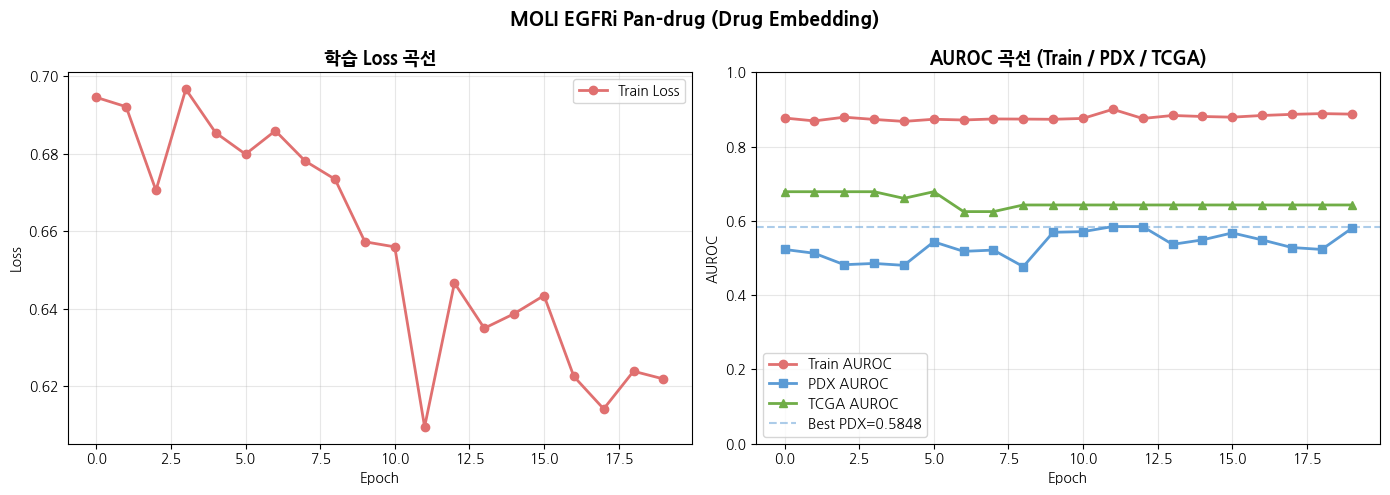

✅ 학습 곡선 저장 완료


In [ ]:
# ===================================================
# 8) 학습 곡선 시각화
# ===================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], '-o', color='#E07070', label='Train Loss', linewidth=2)
axes[0].set_title('학습 Loss 곡선', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUROC
axes[1].plot(history['train_auroc'], '-o', color='#E07070', label='Train AUROC', linewidth=2)
axes[1].plot(history['pdx_auroc'],   '-s', color='#5B9BD5', label='PDX AUROC',   linewidth=2)
axes[1].plot(history['tcga_auroc'],  '-^', color='#70AD47', label='TCGA AUROC',  linewidth=2)
axes[1].axhline(y=best_pdx_auroc, color='#5B9BD5', linestyle='--', alpha=0.5,
                label=f'Best PDX={best_pdx_auroc:.4f}')
axes[1].set_title('AUROC 곡선 (Train / PDX / TCGA)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUROC')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('MOLI EGFRi Pan-drug (Drug Embedding)', fontsize=14, fontweight='bold')
plt.tight_layout()

output_dir = "/content/drive/MyDrive/AI Health care 실습파일/MOLI/outputs/EGFRi"
plt.savefig(f'{output_dir}/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 학습 곡선 저장 완료")